# BabyAI Inference Demo

Load the generated BabyAI inference split, compare pretrained Neural, NeuPSL fine-tuned Neural, and PSL-fused `Action` predictions, then visualize final steps from several trajectories.

In [11]:
from collections import defaultdict
from pathlib import Path
import json
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = Path.cwd()
if not (project_root / 'scripts').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
python = sys.executable

from models.transformer import load_checkpoint

train_size = 50
valid_size = 100
inference_size = 1000

data_root = project_root / 'data' / 'experiment_babyai'
inference_dir = data_root / 'inference' / f'size_{inference_size:04d}'
result_dir = project_root / 'results' / f'babyai_train_{train_size}_infer_{inference_size}'
pretrained_path = project_root / 'ckpt' / 'pretrained-babyai-transformer.pt'
neupsl_model_path = result_dir / 'model.pt'
runtime_output_path = result_dir / 'runtime-output.json'

action_vocab = json.loads((data_root / 'action-vocab.json').read_text())
id_to_action = {value: key for key, value in action_vocab.items()}

project_root

PosixPath('/Users/zmx/Desktop/neupsl-intent')

## 1. Check Required Artifacts

In [12]:
required_paths = [
    inference_dir / 'sequence-data-inference.jsonl',
    pretrained_path,
    neupsl_model_path,
    runtime_output_path,
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Missing inference artifacts. Run scripts/create_data.py and scripts/neupsl_train.py first. Missing: '
        + ', '.join(str(path) for path in missing)
    )

print('Using inference data:', inference_dir)
print('Using pretrained model:', pretrained_path)
print('Using NeuPSL model:', neupsl_model_path)
print('Using PSL runtime output:', runtime_output_path)

Using inference data: /Users/zmx/Desktop/neupsl-intent/data/experiment_babyai/inference/size_1000
Using pretrained model: /Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-babyai-transformer.pt
Using NeuPSL model: /Users/zmx/Desktop/neupsl-intent/results/babyai_train_50_infer_1000/model.pt
Using PSL runtime output: /Users/zmx/Desktop/neupsl-intent/results/babyai_train_50_infer_1000/runtime-output.json


## 2. Load Inference Rows And PSL Predictions

In [13]:
def load_jsonl(path):
    rows = []
    with Path(path).open() as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def parse_psl_action_predictions(path):
    payload = json.loads(Path(path).read_text())
    by_step = defaultdict(dict)
    for atom in payload.get('atoms', []):
        if atom.get('predicate') != 'ACTION':
            continue
        step_id, action_id = atom['arguments']
        by_step[int(step_id)][int(action_id)] = float(atom['value'])
    predictions = {}
    probs = {}
    for step_id, scores in by_step.items():
        vector = np.asarray([scores.get(index, 0.0) for index in range(len(action_vocab))], dtype=float)
        probs[step_id] = vector
        predictions[step_id] = id_to_action[int(np.argmax(vector))]
    return predictions, probs, payload.get('evaluations', [])

rows = load_jsonl(inference_dir / 'sequence-data-inference.jsonl')
psl_preds, psl_probs, psl_evaluations = parse_psl_action_predictions(runtime_output_path)

print('inference step samples:', len(rows))
print('episodes:', len({row['episode_id'] for row in rows}))
print('PSL predictions:', len(psl_preds))
print('PSL evaluations:', psl_evaluations)

inference step samples: 7046
episodes: 1000
PSL predictions: 7046
PSL evaluations: ['Evaluator: CategoricalEvaluator, Predicate: ACTION, Results -- Categorical Accuracy: 0.831394']


## 3. Neural Checkpoint Predictions

In [14]:
def choose_device(device='auto'):
    if device != 'auto':
        return device
    if torch.cuda.is_available():
        return 'cuda'
    if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

def predict_rows(model_path, rows, batch_size=256, device='auto'):
    device = choose_device(device)
    model = load_checkpoint(model_path, map_location=device).to(device)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for start in range(0, len(rows), batch_size):
            batch = rows[start:start + batch_size]
            tokens = torch.as_tensor([row['token_ids'] for row in batch], dtype=torch.long, device=device)
            types = torch.as_tensor([row['type_ids'] for row in batch], dtype=torch.long, device=device)
            probs = model(tokens, types).detach().cpu().numpy()
            all_probs.append(probs)
    all_probs = np.concatenate(all_probs, axis=0)
    pred_ids = np.argmax(all_probs, axis=1)
    preds = [id_to_action[int(index)] for index in pred_ids]
    return preds, all_probs

neural_preds, neural_probs = predict_rows(pretrained_path, rows)
neupsl_preds, neupsl_probs = predict_rows(neupsl_model_path, rows)

print('Loaded neural predictions:', len(neural_preds))
print('Loaded NeuPSL checkpoint predictions:', len(neupsl_preds))

Loaded neural predictions: 7046
Loaded NeuPSL checkpoint predictions: 7046


## 4. Accuracy Summary

In [15]:
truth = np.asarray([row['action'] for row in rows], dtype=object)
psl_aligned = [psl_preds.get(row['step_id'], None) for row in rows]
has_psl = np.asarray([pred is not None for pred in psl_aligned], dtype=bool)

summary = {
    'examples': int(len(rows)),
    'neural_accuracy': float(np.mean(np.asarray(neural_preds, dtype=object) == truth)),
    'neupsl_checkpoint_accuracy': float(np.mean(np.asarray(neupsl_preds, dtype=object) == truth)),
    'psl_fused_action_accuracy': float(np.mean(np.asarray(psl_aligned, dtype=object)[has_psl] == truth[has_psl])),
    'psl_prediction_coverage': float(np.mean(has_psl)),
}
summary

{'examples': 7046,
 'neural_accuracy': 0.371274481975589,
 'neupsl_checkpoint_accuracy': 0.8360772069259154,
 'psl_fused_action_accuracy': 0.8313936985523701,
 'psl_prediction_coverage': 1.0}

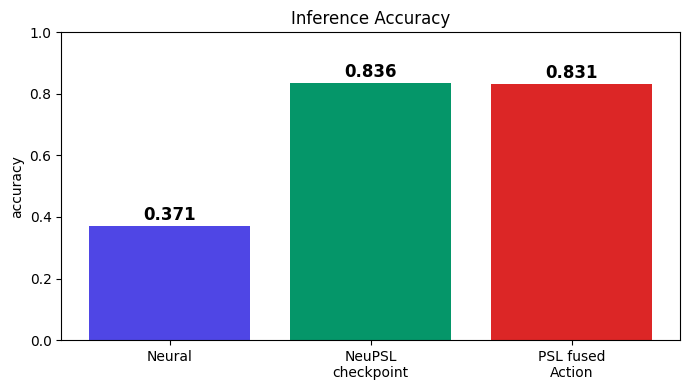

In [16]:
labels = ['Neural', 'NeuPSL\ncheckpoint', 'PSL fused\nAction']
values = [summary['neural_accuracy'], summary['neupsl_checkpoint_accuracy'], summary['psl_fused_action_accuracy']]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=['#4f46e5', '#059669', '#dc2626'])
ax.set_ylim(0, 1)
ax.set_ylabel('accuracy')
ax.set_title('Inference Accuracy')
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()

## 5. Inspect Prediction Rows

In [17]:
def top_actions(prob_vector, top_k=3):
    order = np.argsort(prob_vector)[::-1][:top_k]
    return [(id_to_action[int(index)], float(prob_vector[index])) for index in order]

preview = []
for index, row in enumerate(rows[:12]):
    preview.append({
        'step_id': row['step_id'],
        'episode_id': row['episode_id'],
        'step': row['step_index'],
        'true': row['action'],
        'Neural': neural_preds[index],
        'NeuPSL checkpoint': neupsl_preds[index],
        'PSL fused Action': psl_preds.get(row['step_id']),
        'Neural top3': top_actions(neural_probs[index]),
        'PSL top3': top_actions(psl_probs[row['step_id']]) if row['step_id'] in psl_probs else None,
    })
preview

[{'step_id': 19122,
  'episode_id': 'babyai-pickuploc-v0-00020',
  'step': 0,
  'true': 'left',
  'Neural': 'left',
  'NeuPSL checkpoint': 'left',
  'PSL fused Action': 'left',
  'Neural top3': [('left', 0.5343440771102905),
   ('right', 0.4501555263996124),
   ('forward', 0.012971973046660423)],
  'PSL top3': [('left', 0.848668),
   ('right', 0.05143621),
   ('done', 0.04059539)]},
 {'step_id': 19123,
  'episode_id': 'babyai-pickuploc-v0-00020',
  'step': 1,
  'true': 'forward',
  'Neural': 'left',
  'NeuPSL checkpoint': 'forward',
  'PSL fused Action': 'forward',
  'Neural top3': [('left', 0.7616820931434631),
   ('right', 0.21760563552379608),
   ('forward', 0.01706797629594803)],
  'PSL top3': [('forward', 0.9880537), ('done', 0.0), ('toggle', 0.0)]},
 {'step_id': 19124,
  'episode_id': 'babyai-pickuploc-v0-00020',
  'step': 2,
  'true': 'pickup',
  'Neural': 'left',
  'NeuPSL checkpoint': 'pickup',
  'PSL fused Action': 'pickup',
  'Neural top3': [('left', 0.8400591611862183),
   

## 6. Trajectory-End Visualization

In [18]:
def episode_seed(episode_id):
    match = re.search(r'(\d+)$', episode_id)
    if not match:
        raise ValueError(f'Cannot parse seed from {episode_id}')
    return int(match.group(1))

def render_episode_frames(row, frame_count):
    import gymnasium as gym
    import minigrid  # noqa: F401
    from minigrid.utils.baby_ai_bot import BabyAIBot

    env = gym.make(row['env_id'], render_mode='rgb_array')
    env.reset(seed=episode_seed(row['episode_id']))
    bot = BabyAIBot(env)
    frames = []
    last_action = None
    for frame_index in range(frame_count):
        frames.append(env.render())
        action = bot.replan(last_action)
        _, _, terminated, truncated, _ = env.step(action)
        last_action = action
        if terminated or truncated:
            break
    env.close()
    return frames

def build_episode_panels(rows, focus_actions=('pickup', 'toggle', 'drop'), max_len=6):
    episodes = defaultdict(list)
    for index, row in enumerate(rows):
        item = dict(row)
        item['row_index'] = index
        item['neural_pred'] = neural_preds[index]
        item['neupsl_pred'] = neupsl_preds[index]
        item['psl_pred'] = psl_preds.get(row['step_id'])
        episodes[row['episode_id']].append(item)

    episode_ids = sorted(episodes)
    sorted_episodes = []
    for episode_index, episode_id in enumerate(episode_ids):
        episode = sorted(episodes[episode_id], key=lambda row: row['step_index'])
        sorted_episodes.append((episode_index, episode_id, episode))

    def add_panel(panels, used_episode_ids, episode_index, episode_id, episode, focus_action):
        focus_positions = [i for i, row in enumerate(episode) if row['action'] == focus_action]
        focus_position = focus_positions[-1] if focus_positions else len(episode) - 1
        segment_end = min(len(episode), focus_position + 1)
        segment_start = max(0, segment_end - max_len)
        panels.append({
            'episode_index': episode_index,
            'focus_action': focus_action,
            'episode': episode,
            'segment': episode[segment_start:segment_end],
            'segment_start': segment_start,
        })
        used_episode_ids.add(episode_id)

    panels = []
    used_episode_ids = set()
    for focus_action in focus_actions:
        for episode_index, episode_id, episode in sorted_episodes:
            if episode_id in used_episode_ids:
                continue
            if any(row['action'] == focus_action for row in episode):
                add_panel(panels, used_episode_ids, episode_index, episode_id, episode, focus_action)
                break

    for episode_index, episode_id, episode in sorted_episodes:
        if len(panels) >= 3:
            break
        if episode_id not in used_episode_ids:
            add_panel(panels, used_episode_ids, episode_index, episode_id, episode, episode[-1]['action'])
    return panels

panels = build_episode_panels(rows, focus_actions=('pickup', 'toggle', 'drop'), max_len=6)
[
    {
        'episode_index': panel['episode_index'],
        'episode_id': panel['segment'][0]['episode_id'],
        'focus_action': panel['focus_action'],
        'shown_steps': [row['step_index'] for row in panel['segment']],
        'rows': [(row['step_index'], row['action'], row['neural_pred'], row['neupsl_pred'], row['psl_pred']) for row in panel['segment']],
    }
    for panel in panels
]

[{'episode_index': 500,
  'episode_id': 'babyai-pickuploc-v0-00020',
  'focus_action': 'pickup',
  'shown_steps': [0, 1, 2],
  'rows': [(0, 'left', 'left', 'left', 'left'),
   (1, 'forward', 'left', 'forward', 'forward'),
   (2, 'pickup', 'left', 'pickup', 'pickup')]},
 {'episode_index': 0,
  'episode_id': 'babyai-opendoor-v0-00021',
  'focus_action': 'toggle',
  'shown_steps': [1, 2, 3, 4, 5, 6],
  'rows': [(1, 'forward', 'right', 'forward', 'forward'),
   (2, 'forward', 'forward', 'forward', 'forward'),
   (3, 'forward', 'forward', 'forward', 'forward'),
   (4, 'forward', 'forward', 'forward', 'forward'),
   (5, 'right', 'right', 'right', 'right'),
   (6, 'toggle', 'toggle', 'toggle', 'toggle')]},
 {'episode_index': 755,
  'episode_id': 'babyai-pickuploc-v0-00565',
  'focus_action': 'drop',
  'shown_steps': [0, 1, 2, 3, 4],
  'rows': [(0, 'left', 'left', 'left', 'left'),
   (1, 'pickup', 'left', 'pickup', 'pickup'),
   (2, 'left', 'forward', 'forward', 'forward'),
   (3, 'left', 'rig

**Legend**

- `true`: BabyAIBot expert next action.
- `Neural`: pretrained Transformer prediction.
- `NeuPSL`: neural checkpoint after NeuPSL fine-tuning.
- `PSL`: PSL-fused `Action` prediction parsed from `runtime-output.json`.
- Green titles mean the PSL prediction matches `true`; red titles mean it does not.
- The panels are selected to cover different expert target actions where available: `pickup`, `toggle`/open-door, and `drop` if such a step exists in the inference split.

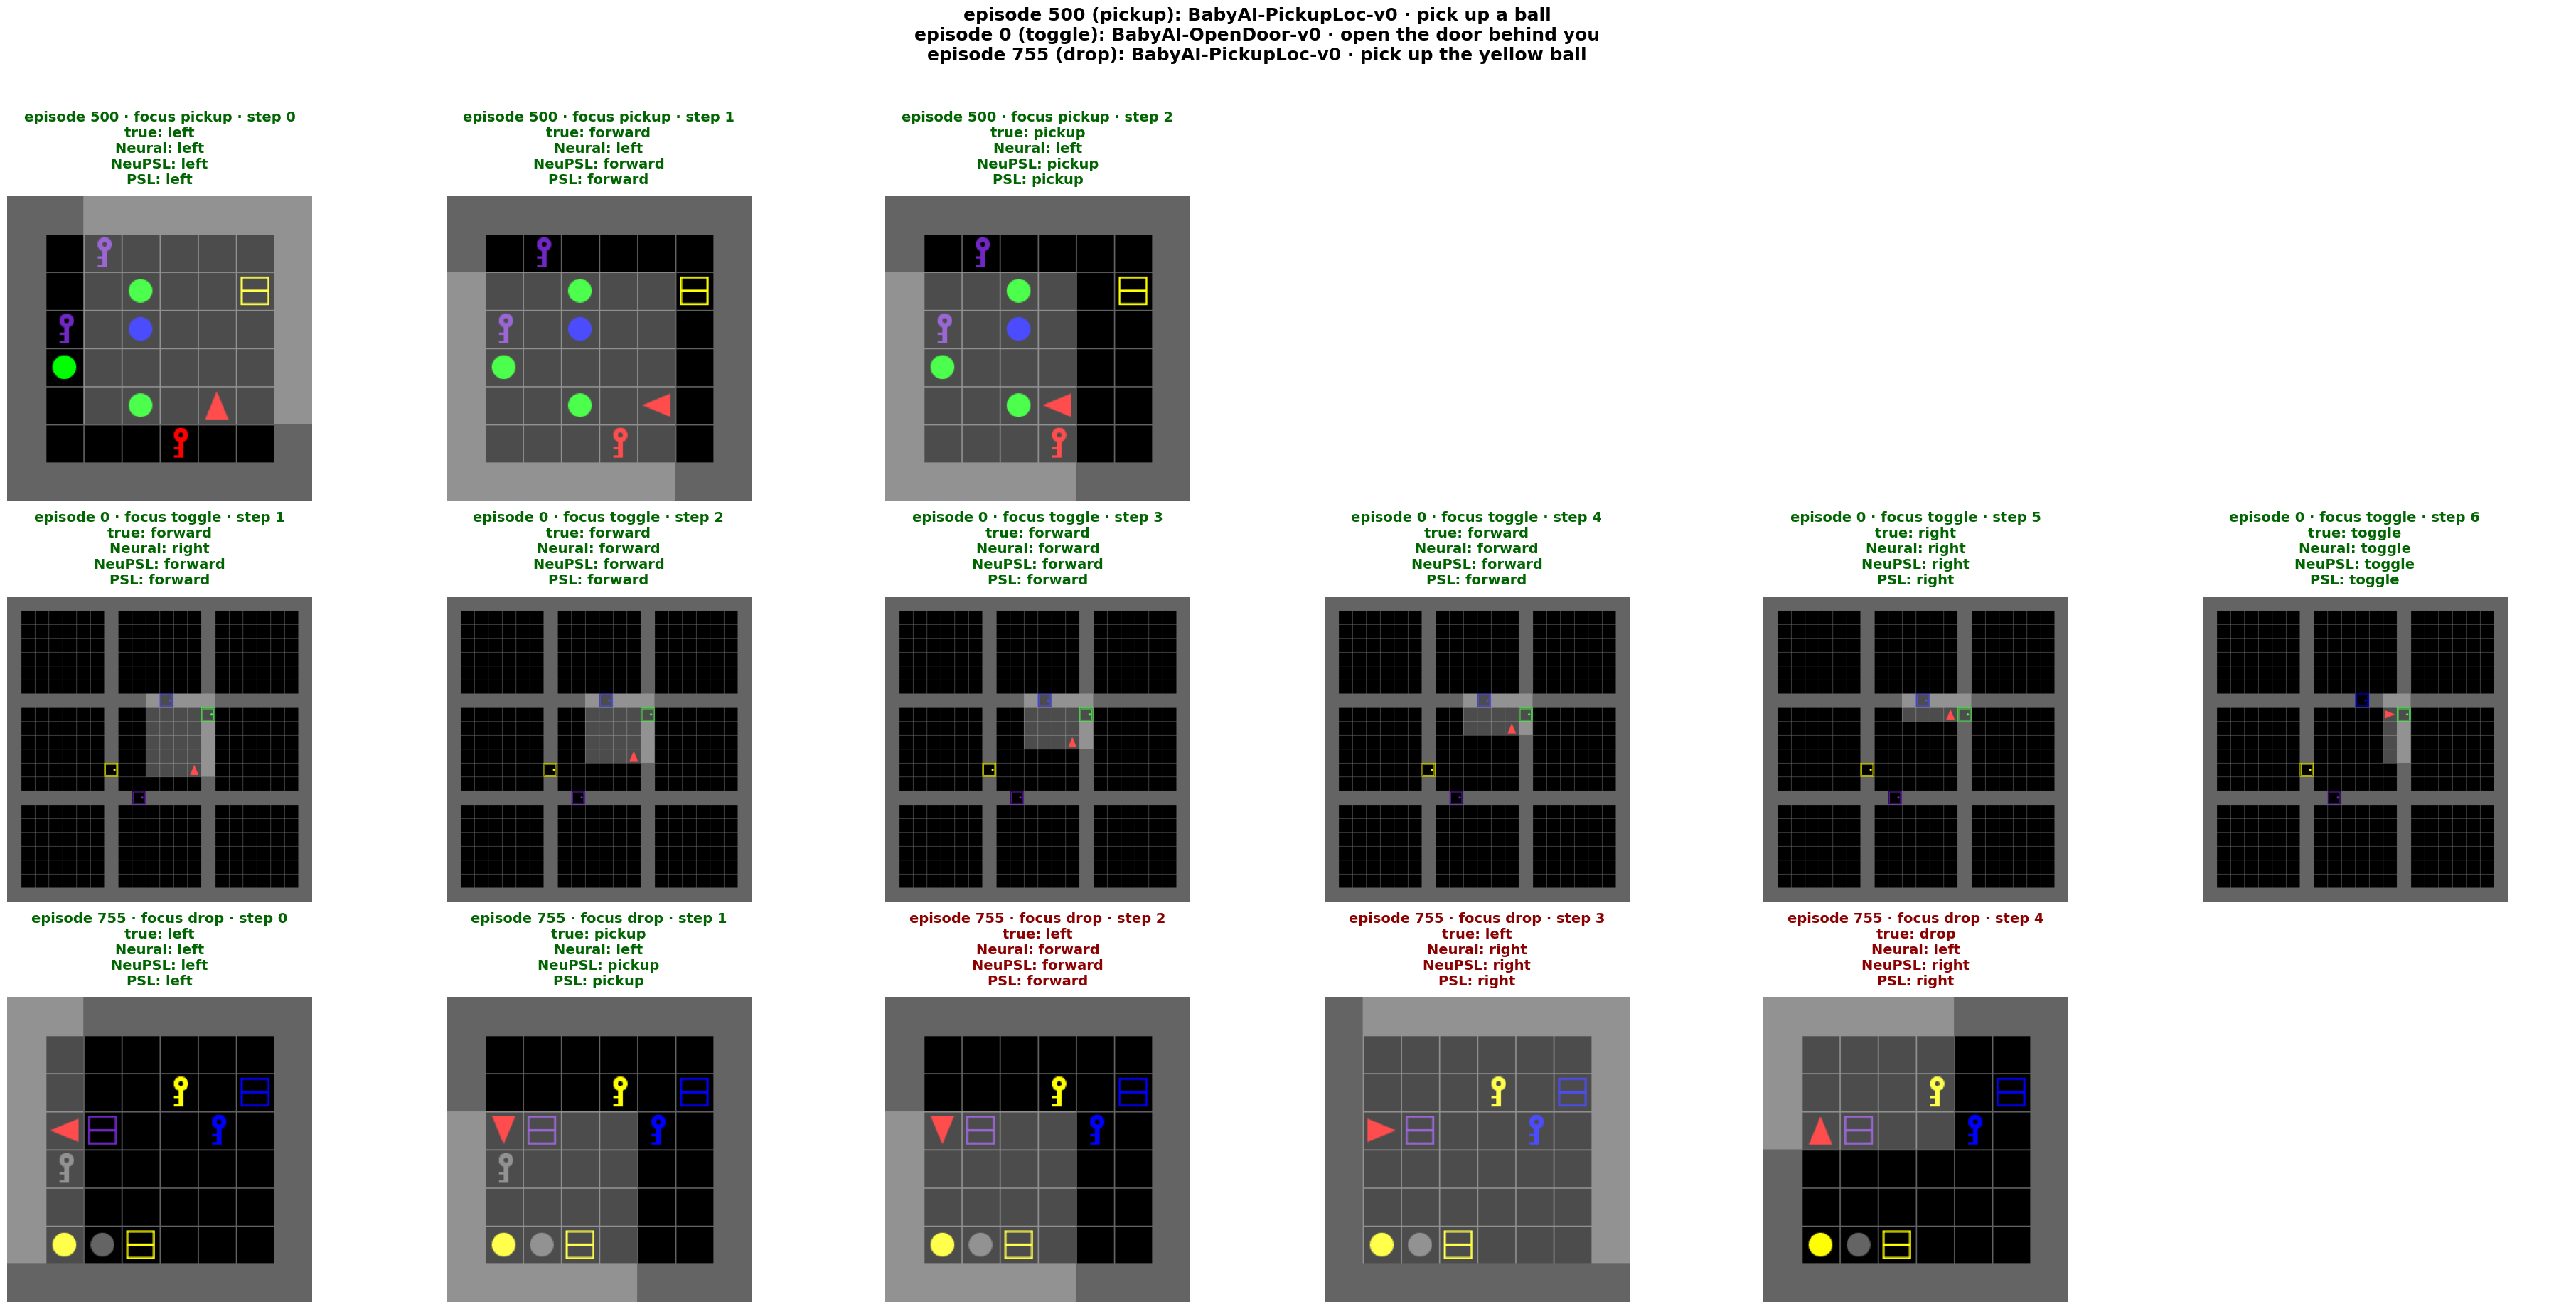

In [19]:
max_cols = max(len(panel['segment']) for panel in panels)
fig, axes = plt.subplots(len(panels), max_cols, figsize=(6.2 * max_cols, 6.0 * len(panels)))
axes = np.asarray(axes).reshape(len(panels), max_cols)

for row_index, panel in enumerate(panels):
    segment = panel['segment']
    frames = render_episode_frames(panel['episode'][0], panel['segment_start'] + len(segment))
    frames = frames[panel['segment_start']:panel['segment_start'] + len(segment)]
    for col_index in range(max_cols):
        ax = axes[row_index, col_index]
        ax.axis('off')
        if col_index >= len(segment):
            continue
        row = segment[col_index]
        frame = frames[col_index]
        psl = row['psl_pred']
        correct_psl = psl == row['action']
        ax.imshow(frame)
        title = (
            f"episode {panel['episode_index']} · focus {panel['focus_action']} · step {row['step_index']}\n"
            f"true: {row['action']}\n"
            f"Neural: {row['neural_pred']}\n"
            f"NeuPSL: {row['neupsl_pred']}\n"
            f"PSL: {psl}"
        )
        ax.set_title(
            title,
            color='darkgreen' if correct_psl else 'darkred',
            fontsize=14,
            fontweight='bold',
            pad=12,
        )

mission_lines = [f"episode {panel['episode_index']} ({panel['focus_action']}): {panel['segment'][0]['env_id']} · {panel['segment'][0]['mission']}" for panel in panels]
fig.suptitle('\n'.join(mission_lines), y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()

## 7. Save Metrics

In [20]:
metrics_path = result_dir / 'inference-demo-metrics.json'
metrics_path.write_text(json.dumps(summary, indent=2, sort_keys=True), encoding='utf-8')
metrics_path

PosixPath('/Users/zmx/Desktop/neupsl-intent/results/babyai_train_50_infer_1000/inference-demo-metrics.json')